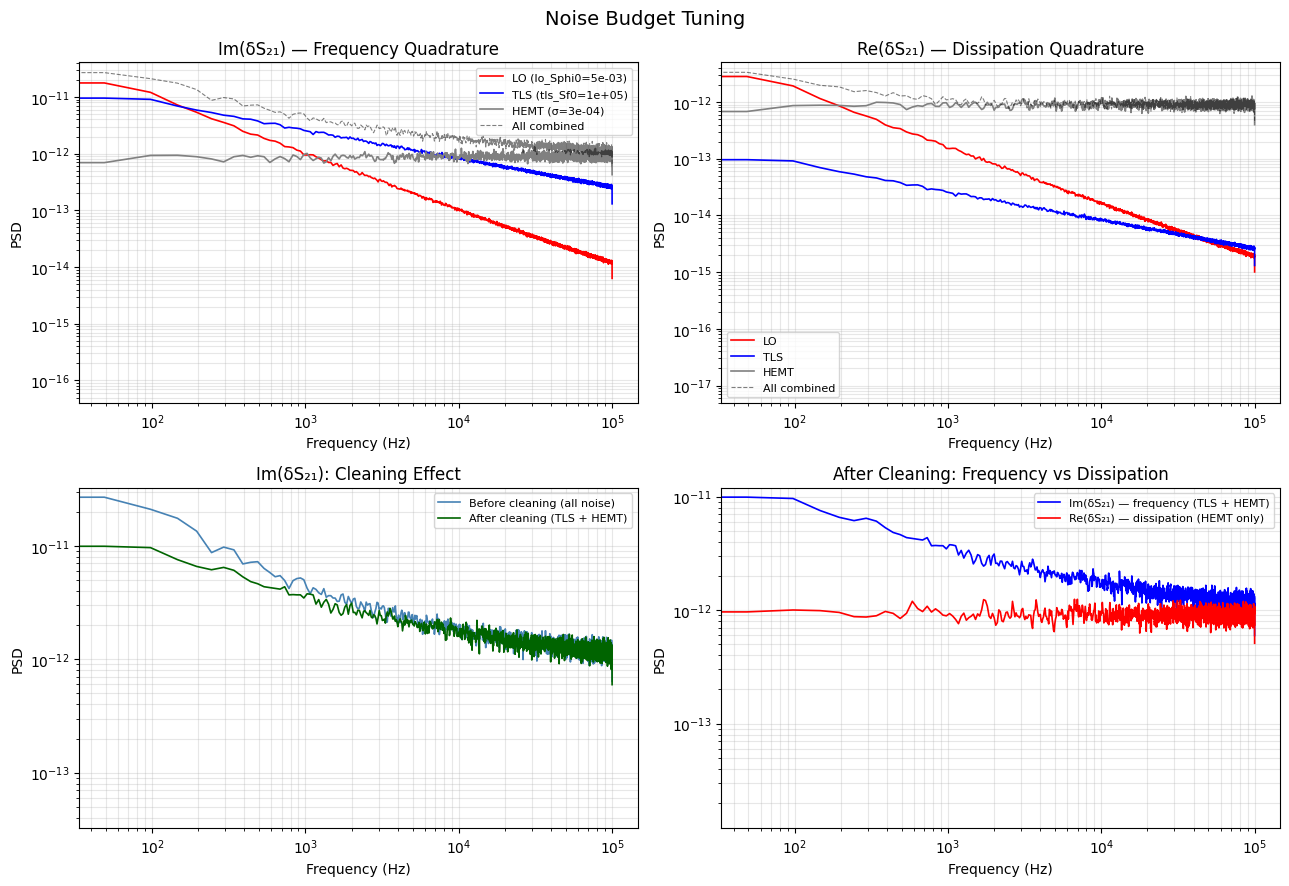


Noise levels at key frequencies (Im(δS₂₁) PSD):
Freq (Hz)    LO           TLS          HEMT         Dominant    
------------------------------------------------------------
1            3.12e-12     1.52e-12     1.17e-13     LO          
10           3.12e-12     1.52e-12     1.17e-13     LO          
100          1.20e-11     9.07e-12     9.31e-13     LO          
1000         9.53e-13     2.57e-12     9.69e-13     TLS         
10000        1.02e-13     8.67e-13     8.43e-13     TLS         

--- Tuning guide ---
Want LO > TLS at low freq?  → Increase lo_Sphi0 or decrease tls_Sf0
Want TLS visible after clean? → Increase tls_Sf0 or decrease hemt_sigma
Want diss. quad white?        → Already true if TLS only shifts fr (not Qi)
Want more separation?         → Increase lo_Sphi0/tls_Sf0 ratio


In [11]:
import numpy as np
import matplotlib.pyplot as plt

from mkid import MKID, ReadoutParams, NoiseParams, PulseParams
from scipy.signal import welch, csd as scipy_csd


def PSD(x, fs=200e3, nperseg=4096):
    """Power spectral density."""
    freqs, psd = welch(x, fs=fs, nperseg=nperseg, window='hann')
    return freqs, psd

def plot_PSD_grid(panels, fs=200e3, nperseg=4096, n_decades=4,
                  figsize=(14, 7), suptitle=None):
    """
    Plot a grid of PSD panels.
    
    Args:
        panels: list of lists defining the grid. Each entry is a dict:
            {
                'traces': [(array, label, color), ...],
                'title': str,
                'ylabel': str,
                'ylim': (lo, hi) or None,   # optional manual override
                'xlim': (lo, hi) or None,   # optional manual override
            }
            Organized as panels[row][col].
        fs: sample rate (Hz)
        nperseg: PSD segment length
        n_decades: auto y-range decades below max (used if ylim not set)
        figsize: figure size
        suptitle: figure title
        
    Returns:
        fig, axes
        
    Example:
        panels = [
            [  # Row 0
                {'traces': [(dI_det, 'Det I', 'steelblue'),
                            (dI_clean, 'Clean I', 'darkorange')],
                 'title': 'Electronics: I', 'ylabel': 'PSD (ADCu²/Hz)'},
                {'traces': [(dS21_det.real, 'Det', 'steelblue')],
                 'title': 'Re(δS₂₁)', 'ylabel': 'PSD (δS₂₁²/Hz)'},
            ],
            [  # Row 1
                ...
            ],
        ]
        fig, axes = plot_PSD_grid(panels)
    """
    nrows = len(panels)
    ncols = max(len(row) for row in panels)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    
    # Ensure axes is always a 2D array
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    
    for i, row in enumerate(panels):
        for j, panel in enumerate(row):
            ax = axes[i, j]
            
            for trace in panel['traces']:
                data, label, color = trace
                freqs, psd = PSD(data, fs=fs, nperseg=nperseg)
                ax.loglog(freqs, psd, color=color, lw=0.8, label=label)
            
            ax.set_title(panel.get('title', ''), fontsize=10)
            ax.set_ylabel(panel.get('ylabel', ''), fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3, which='both')
            
            if i == nrows - 1:
                ax.set_xlabel('Frequency (Hz)')
            
            # Y-limits: manual or auto
            if panel.get('ylim'):
                ax.set_ylim(panel['ylim'])
            else:
                ymax = ax.get_ylim()[1]
                ax.set_ylim(bottom=ymax / 10**n_decades, top=ymax * 2)
            
            # X-limits: manual or auto
            if panel.get('xlim'):
                ax.set_xlim(panel['xlim'])
    
    plt.tight_layout()
    plt.show()
    return fig, axes



# ============================================================
# NOISE TUNING SCRIPT
# 
# Goal: Set noise levels so that:
#   1. LO dominates at low freq (cleanable)
#   2. TLS is revealed after cleaning
#   3. Dissipation quadrature is nearly white after cleaning
# ============================================================

# --- Adjust these until the plot looks right ---
noise_params = NoiseParams(
    tls_Sf0=1e5,         # TLS: 1/f frequency noise amplitude at 1 Hz
    tls_alpha=0.5,       # TLS: spectral slope (1/f^0.5)
    hemt_sigma=0.0003,    # HEMT: white noise floor in IQ
    lo_Sphi0=5e-3,       # LO: phase noise amplitude at 1 Hz (DOMINANT)
    lo_alpha=1.0,        # LO: spectral slope (1/f)
    lo_white=1e-8,       # LO: white floor (so it rolls off at high freq)
)

m = MKID(
    fr=5.0e9, Qi=200000, Qc=50000, phi_c=0.1, tau=50e-9,
    pulse_params=PulseParams(
        tau_rise=5e-4,
        tau_fall=1e-2,
        Tc=1.2,
        alpha_f=0.05,
        alpha_Q=0.05,
        T_bath=0.1,
        C_override=8e-17,
    ),
    noise_params=noise_params,
    readout_params=ReadoutParams(
        f_tone=5.0e9,
        f_clean=[5.0e9 - 2.0e6, 5.0e9 + 2.5e6],
        fs=200e3,
    ),
    seed=42,
)

# ============================================================
# Generate noise-only timestreams (no photons, one source at a time)
# ============================================================

empty_t = np.array([])
empty_E = np.array([])

data_lo_only = m.timestream_fast(
    duration=1.0, photon_times=empty_t, photon_energies=empty_E,
    include_tls=False, include_hemt=False, include_lo=True)

data_tls_only = m.timestream_fast(
    duration=1.0, photon_times=empty_t, photon_energies=empty_E,
    include_tls=True, include_hemt=False, include_lo=False)

data_hemt_only = m.timestream_fast(
    duration=1.0, photon_times=empty_t, photon_energies=empty_E,
    include_tls=False, include_hemt=True, include_lo=False)

data_all = m.timestream_fast(
    duration=1.0, photon_times=empty_t, photon_energies=empty_E,
    include_tls=True, include_hemt=True, include_lo=True)

# ============================================================
# Convert to fractional δS21 basis
# ============================================================

def to_dS21(data, m):
    """Convert IQ timestream to δS21 (cable-removed, quiescent-subtracted)."""
    S21_raw = data.I_det + 1j * data.Q_det
    cable = m.resonator.a * np.exp(-2j * np.pi * m.resonator.tau * (m.readout.f_tone - m.resonator.fr))
    S21_ideal = S21_raw / cable
    S21_on_res = np.mean(S21_ideal[:1000])
    return S21_ideal - S21_on_res

dS21_lo = to_dS21(data_lo_only, m)
dS21_tls = to_dS21(data_tls_only, m)
dS21_hemt = to_dS21(data_hemt_only, m)
dS21_all = to_dS21(data_all, m)

# ============================================================
# Plot noise budget: frequency quadrature Im(δS21)
# ============================================================

fs = m.readout.fs

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Noise Budget Tuning', fontsize=14)

# --- Top left: Individual noise sources in Im(δS21) ---
ax = axes[0, 0]
freqs, psd = PSD(dS21_lo.imag, fs=fs)
ax.loglog(freqs, psd, 'r-', lw=1.2, label=f'LO (lo_Sphi0={noise_params.lo_Sphi0:.0e})')
freqs, psd = PSD(dS21_tls.imag, fs=fs)
ax.loglog(freqs, psd, 'b-', lw=1.2, label=f'TLS (tls_Sf0={noise_params.tls_Sf0:.0e})')
freqs, psd = PSD(dS21_hemt.imag, fs=fs)
ax.loglog(freqs, psd, 'gray', lw=1.2, label=f'HEMT (σ={noise_params.hemt_sigma:.0e})')
freqs, psd = PSD(dS21_all.imag, fs=fs)
ax.loglog(freqs, psd, 'k--', lw=0.8, alpha=0.5, label='All combined')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title('Im(δS₂₁) — Frequency Quadrature')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ymax = ax.get_ylim()[1]
ax.set_ylim(bottom=ymax/1e6)

# --- Top right: Dissipation quadrature Re(δS21) ---
ax = axes[0, 1]
freqs, psd = PSD(dS21_lo.real, fs=fs)
ax.loglog(freqs, psd, 'r-', lw=1.2, label='LO')
freqs, psd = PSD(dS21_tls.real, fs=fs)
ax.loglog(freqs, psd, 'b-', lw=1.2, label='TLS')
freqs, psd = PSD(dS21_hemt.real, fs=fs)
ax.loglog(freqs, psd, 'gray', lw=1.2, label='HEMT')
freqs, psd = PSD(dS21_all.real, fs=fs)
ax.loglog(freqs, psd, 'k--', lw=0.8, alpha=0.5, label='All combined')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title('Re(δS₂₁) — Dissipation Quadrature')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ymax = ax.get_ylim()[1]
ax.set_ylim(bottom=ymax/1e6)

# --- Bottom left: Before/after cleaning (frequency quad) ---
ax = axes[1, 0]

# Simulate cleaning: LO is common-mode, so after cleaning we remove it
# "After cleaning" ≈ TLS + HEMT (the uncorrelated part)
freqs, psd_before = PSD(dS21_all.imag, fs=fs)
# Approximate "after cleaning" as TLS + HEMT (no LO)
data_after_clean = m.timestream_fast(
    duration=1.0, photon_times=empty_t, photon_energies=empty_E,
    include_tls=True, include_hemt=True, include_lo=False)
dS21_after = to_dS21(data_after_clean, m)
freqs, psd_after = PSD(dS21_after.imag, fs=fs)

ax.loglog(freqs, psd_before, 'steelblue', lw=1.2, label='Before cleaning (all noise)')
ax.loglog(freqs, psd_after, 'darkgreen', lw=1.2, label='After cleaning (TLS + HEMT)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title('Im(δS₂₁): Cleaning Effect')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ymax = ax.get_ylim()[1]
ax.set_ylim(bottom=ymax/1e3)

# --- Bottom right: After cleaning, both quadratures ---
ax = axes[1, 1]
freqs, psd_freq = PSD(dS21_after.imag, fs=fs)
freqs, psd_diss = PSD(dS21_after.real, fs=fs)
ax.loglog(freqs, psd_freq, 'b-', lw=1.2, label='Im(δS₂₁) — frequency (TLS + HEMT)')
ax.loglog(freqs, psd_diss, 'r-', lw=1.2, label='Re(δS₂₁) — dissipation (HEMT only)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title('After Cleaning: Frequency vs Dissipation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ymax = ax.get_ylim()[1]
ax.set_ylim(bottom=ymax/1e3)

plt.tight_layout()
plt.show()

# ============================================================
# Print diagnostic: crossover frequencies
# ============================================================

freqs_check = [1, 10, 100, 1000, 10000]
print("\nNoise levels at key frequencies (Im(δS₂₁) PSD):")
print(f"{'Freq (Hz)':<12} {'LO':<12} {'TLS':<12} {'HEMT':<12} {'Dominant':<12}")
print("-" * 60)

f_psd, psd_lo = PSD(dS21_lo.imag, fs=fs)
_, psd_tls = PSD(dS21_tls.imag, fs=fs)
_, psd_hemt = PSD(dS21_hemt.imag, fs=fs)

for fc in freqs_check:
    idx = np.argmin(np.abs(f_psd - fc))
    lo_val = psd_lo[idx]
    tls_val = psd_tls[idx]
    hemt_val = psd_hemt[idx]
    dominant = 'LO' if lo_val > tls_val and lo_val > hemt_val else \
               'TLS' if tls_val > hemt_val else 'HEMT'
    print(f"{fc:<12} {lo_val:<12.2e} {tls_val:<12.2e} {hemt_val:<12.2e} {dominant:<12}")

print("\n--- Tuning guide ---")
print("Want LO > TLS at low freq?  → Increase lo_Sphi0 or decrease tls_Sf0")
print("Want TLS visible after clean? → Increase tls_Sf0 or decrease hemt_sigma")
print("Want diss. quad white?        → Already true if TLS only shifts fr (not Qi)")
print("Want more separation?         → Increase lo_Sphi0/tls_Sf0 ratio")